In [1]:
import os
from pyhere import here

project_dir = here(".")
os.chdir(project_dir)

print(os.getcwd())


/Users/work/Data Science/sheffield-bats


In [2]:
%load_ext autoreload
%autoreload 2

import json

import elapid as ela
import geopandas as gpd
import rioxarray as rxr

from sklearn.metrics import roc_auc_score
from folium import Map, GeoJson, CircleMarker
from matplotlib import pyplot as plt


from sdm.models.utils.utils import prepare_occurrence_data
from sdm.models.maxent.maxent_model import evaluate_and_train_maxent_model
from sdm.raster.io import load_environmental_variables
from sdm.raster.utils import generate_point_grid
from sdm.occurrence.species_data import latin_name, activity_type, genus
from sdm.utils.io import load_config
from sdm.utils.io import load_boundary

from pathlib import Path

In [3]:
# load the config
config = load_config()
config


{'paths': {'raw_data': 'data/raw',
  'processed_data': 'data/processed',
  'models': 'data/sdm_models',
  'tuning_dir': 'data/sdm_tuning',
  'predictions': 'data/sdm_predictions',
  'model_config': 'model_config.yml',
  'variables_config': 'variables_config.yml',
  'occurence_data': 'data/processed/bats-tidy.geojson',
  'background_points': 'data/processed/background-points.geojson',
  'boundary': 'data/processed/boundary.geojson',
  'grid_points': 'data/evs/grid-points.parquet',
  'evs': 'data/processed/evs',
  'ev_tiff': 'data/evs/evs-to-model.tif'},
 'spatial': {'top': 646900,
  'left': 313000,
  'crs': 'EPSG:27700',
  'resolution': 100,
  'study_area_buffer': 7000},
 'crs': 'EPSG:27700',
 'mlflow': {'tracking_uri': 'sqlite:///mlflow.db',
  'experiment_name': 'species_sdm_experiment'}}

In [4]:
import topojson as tp

boundary = load_boundary(
    filepath=config["paths"]["boundary"], buffer_distance=0, target_crs=27700
)

# simplify the boundary to regions to make the calculation faster
boundary_tp = tp.Topology(boundary, prequantize=True)
boundary_tp.toposimplify(100, inplace=True)
boundary = boundary_tp.to_gdf()
boundary["geometry"] = boundary.geometry.make_valid()
boundary["geometry"] = boundary.geometry.buffer(0)


boundary_4326 = boundary.to_crs(4326)
boundary_4326

,geometry,County
0,"MULTIPOLYGON (((-0.92927 53.77354, -0.93328 53...",East Riding of Yorkshire
1,"MULTIPOLYGON (((-0.78862 54.56019, -0.78826 54...",North Yorkshire
2,"POLYGON ((-1.82224 53.52109, -1.80427 53.537, ...",South Yorkshire
3,"POLYGON ((-1.82224 53.52109, -1.82714 53.52349...",West Yorkshire


# Environmental Variables

In [5]:
evs_to_model, ev_path = load_environmental_variables(config["paths"]["ev_tiff"])

all_env_var_names = list(evs_to_model.data_vars.keys())
evs_to_model

<xarray.Dataset> Size: 1GB
Dimensions:                                   (x: 1930, y: 1544)
Coordinates:
  * x                                         (x) float64 15kB 3.562e+05 ... ...
  * y                                         (y) float64 12kB 3.716e+05 ... ...
    spatial_ref                               int64 8B 0
Data variables: (12/95)
    climate_stats_temp_ann_var                (y, x) float32 12MB ...
    climate_bioclim_bio_4                     (y, x) float32 12MB ...
    climate_bioclim_bio_7                     (y, x) float32 12MB ...
    climate_bioclim_bio_2                     (y, x) float32 12MB ...
    climate_stats_prec_ann_var                (y, x) float32 12MB ...
    terrain_dtm                               (y, x) float32 12MB ...
    ...                                        ...
    ceh_landcover_suburban_1500m              (y, x) float32 12MB ...
    os_cover_buildings_1500m                  (y, x) float32 12MB ...
    os_cover_water_1500m                      (y, x) float32 12MB ...
    ceh_landcover_coniferous_woodland_1500m   (y, x) float32 12MB ...
    ceh_landcover_urban_1500m                 (y, x) float32 12MB ...
    ceh_landcover_improved_grassland_1500m    (y, x) float32 12MB ...
Attributes:
    AREA_OR_POINT:  Area

In [6]:
## Convert the env vars to a dataframe to make it easy to join with occurence

ev_df = evs_to_model.to_dataframe()
ev_df.reset_index(inplace=True)
ev_gdf = gpd.GeoDataFrame(ev_df, geometry=gpd.points_from_xy(ev_df.x, ev_df.y))
ev_gdf.crs = evs_to_model.rio.crs
ev_gdf = ev_gdf.drop(columns=["spatial_ref"])
ev_gdf.rename(columns={"x": "grid_x", "y": "grid_y"}, inplace=True)

# Drop rows with missing values - can't be used for modelling
# TODO: interpolate missing values
ev_gdf.dropna(inplace=True)

ev_gdf.head()


,grid_x,grid_y,climate_stats_temp_ann_var,climate_bioclim_bio_4,climate_bioclim_bio_7,climate_bioclim_bio_2,climate_stats_prec_ann_var,terrain_dtm,climate_bioclim_bio_19,climate_bioclim_bio_13,...,vom_vegetation_height_std_1500m,ceh_landcover_broadleaved_woodland_1500m,vom_vegetation_height_mean_1500m,ceh_landcover_suburban_1500m,os_cover_buildings_1500m,os_cover_water_1500m,ceh_landcover_coniferous_woodland_1500m,ceh_landcover_urban_1500m,ceh_landcover_improved_grassland_1500m,geometry
25691,357850.0,470350.0,4.166143,436.094513,17.922857,6.568089,25.374966,32.633919,335.757172,140.925339,...,1.850352,929.000000,0.980535,175.666672,1.041111,2.926667,17.000000,54.777779,7506.222168,POINT (357850 470350)
25692,357850.0,470450.0,4.165142,435.929230,17.912872,6.566302,25.374966,34.947315,336.490479,141.167114,...,1.831626,894.444458,0.954079,183.111115,1.027778,2.957778,16.777779,55.333332,7586.000000,POINT (357850 470450)
25693,357850.0,470550.0,4.164124,435.769379,17.903704,6.564719,25.374966,36.411514,337.228729,141.408264,...,1.812110,868.333313,0.928953,178.555557,1.027778,3.041111,16.777779,49.888889,7624.333496,POINT (357850 470550)
25694,357850.0,470650.0,4.162974,435.644836,17.900000,6.564537,25.656248,37.293659,337.984802,141.640381,...,1.820032,862.000000,0.926465,177.555557,1.024444,3.122222,15.777778,44.444443,7648.111328,POINT (357850 470650)
25695,357850.0,470750.0,4.161742,435.544098,17.900000,6.565303,25.615751,40.439396,338.751831,141.866165,...,1.846067,853.666687,0.933607,182.222229,1.046667,3.153333,15.555555,45.222221,7720.888672,POINT (357850 470750)


# Load the Occurence

In [7]:
# load the occurrence data
bat_records = gpd.read_file(config["paths"]["occurence_data"])
bat_records = bat_records[bat_records.accuracy <= 100]


from leafmap.deckgl import Map

map_center = boundary_4326.union_all().centroid
m = Map(center=(map_center.y, map_center.x), zoom=7)

m.add_gdf(
    boundary,
    zoom_to_layer=False,
    get_fill_color=[60, 60, 60, 40],
)

m.add_gdf(
    bat_records,
    zoom_to_layer=False,
    get_radius=500,
    # pink
    get_fill_color=[255, 192, 203, 180],
)

m


Map(custom_attribution='', layers=(SolidPolygonLayer(get_fill_color=[60, 60, 60, 40], table=arro3.core.Table
+…

# Pick Species


In [8]:
latin_name = "Pipistrellus pipistrellus"
activity_type = "In flight"

# Generate Data

<Axes: >

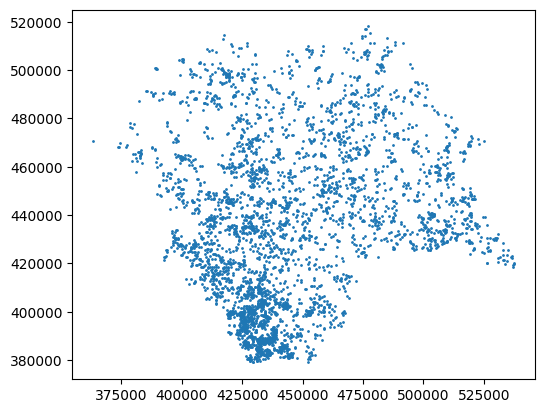

In [9]:
from sdm.occurrence.sampling import (
    generate_background_points_from_data,
    BackgroundMethod,
    TransformMethod,
)
## This is too slow
# TODO: make it faster

# genrate the background points
background_points, density_array = generate_background_points_from_data(
    occurrence_data=bat_records,  # [bat_records.activity_type == activity_type],
    boundary=boundary,
    n_background_points=4000,
    background_method=BackgroundMethod.CONTRAST,
    background_value=0.00,
    sigma=6.5,
    transform_method=TransformMethod.PRESENCE,
    # region_weighting_factor=0.5,
    clip_to_boundary=True,
)

background_points.rename(columns={"presence": "class"}, inplace=True)

background_points.plot(
    markersize=1,
)

In [10]:
# use leafmap foliumap to plot the map
from leafmap.foliumap import Map
from folium import GeoJson, CircleMarker


centroid = boundary_4326.union_all().centroid
m = Map(location=[centroid.y, centroid.x], zoom_start=8, tiles="CartoDB positron")

# Add boundary
GeoJson(
    boundary, style_function=lambda x: {"fillColor": "none", "color": "black"}
).add_to(m)


# Add background points
GeoJson(
    background_points,
    style_function=lambda x: {
        "fillColor": "green",
        "color": "green",
        "radius": 3,
        "fillOpacity": 1,
        "weight": 0.5,
    },
    marker=CircleMarker(radius=3),
).add_to(m)

# Add bats points
GeoJson(
    bat_records[["geometry"]],
    style_function=lambda x: {
        "color": "orange",
        "fillColor": "orange",
        "radius": 3,
        "weight": 0.5,
        "fillOpacity": 1,
    },
    marker=CircleMarker(radius=3),
).add_to(m)

m


## Prepare Training Data

In [11]:
split_keys = ["latin_name", "activity_type"]

bat_records = bat_records[split_keys + ["geometry"]]
bat_records["class"] = 1
bat_records[split_keys].value_counts().to_frame()


count
latin_name                activity_type       
Pipistrellus pipistrellus Roost           4075
                          In flight       3258
Plecotus auritus          Roost           1548
Pipistrellus pygmaeus     Roost           1067
Myotis nattereri          Roost            707
Pipistrellus pygmaeus     In flight        602
Nyctalus noctula          In flight        559
Myotis daubentonii        In flight        441
                          Roost            424
Nyctalus noctula          Roost            273
Myotis mystacinus         Roost            249
Plecotus auritus          In flight        225
Nyctalus leisleri         In flight        172
Myotis nattereri          In flight         72
Nyctalus leisleri         Roost             50
Myotis brandtii           Roost             47
Myotis mystacinus         In flight         39
Pipistrellus nathusii     Roost             32
                          In flight         15
Myotis brandtii           In flight         13
Eptesicus serotinus       In flight          4
Vespertilio murinus       In flight          1

In [12]:
## Annotate the points with the environmental variables
resolution = evs_to_model.rio.resolution()
tolerance = abs(resolution[0])

occurence_data = gpd.sjoin_nearest(
    bat_records, ev_gdf, how="inner", max_distance=tolerance
)
background_data = gpd.sjoin_nearest(
    background_points, ev_gdf, how="inner", max_distance=tolerance
)

occurence_data.drop(columns=["index_right"], inplace=True)
background_data.drop(columns=["index_right"], inplace=True)

occurence_data.head()


,latin_name,activity_type,geometry,class,grid_x,grid_y,climate_stats_temp_ann_var,climate_bioclim_bio_4,climate_bioclim_bio_7,climate_bioclim_bio_2,...,vom_vegetation_height_max_1500m,vom_vegetation_height_std_1500m,ceh_landcover_broadleaved_woodland_1500m,vom_vegetation_height_mean_1500m,ceh_landcover_suburban_1500m,os_cover_buildings_1500m,os_cover_water_1500m,ceh_landcover_coniferous_woodland_1500m,ceh_landcover_urban_1500m,ceh_landcover_improved_grassland_1500m
0,Nyctalus noctula,In flight,POINT (465350 457750),1,465350.0,457750.0,4.370765,457.289093,19.998690,7.670608,...,9.595185,2.277521,1001.111084,1.572917,398.333344,1.483333,3.298889,255.888885,144.777771,5373.888672
1,Nyctalus noctula,In flight,POINT (429550 477250),1,429550.0,477250.0,4.276229,447.886993,19.274574,7.206034,...,10.218222,2.400440,1222.777832,1.511334,240.111115,1.055556,6.936666,25.222221,119.888885,3014.111084
2,Nyctalus noctula,In flight,POINT (446450 435450),1,446450.0,435450.0,4.431757,461.542175,20.190638,7.692239,...,5.131075,1.140973,1044.222168,0.602043,164.777771,0.703333,0.950000,3.111111,43.000000,1135.444458
3,Nyctalus noctula,In flight,POINT (439650 467050),1,439650.0,467050.0,4.357553,455.122711,19.600000,7.385443,...,8.706750,1.794124,226.777771,0.793321,1622.777832,8.766666,2.302222,23.555555,734.555542,2476.888916
4,Nyctalus noctula,In flight,POINT (429550 477250),1,429550.0,477250.0,4.276229,447.886993,19.274574,7.206034,...,10.218222,2.400440,1222.777832,1.511334,240.111115,1.055556,6.936666,25.222221,119.888885,3014.111084


In [13]:
background_data.head()

,geometry,class,density,grid_x,grid_y,climate_stats_temp_ann_var,climate_bioclim_bio_4,climate_bioclim_bio_7,climate_bioclim_bio_2,climate_stats_prec_ann_var,...,vom_vegetation_height_max_1500m,vom_vegetation_height_std_1500m,ceh_landcover_broadleaved_woodland_1500m,vom_vegetation_height_mean_1500m,ceh_landcover_suburban_1500m,os_cover_buildings_1500m,os_cover_water_1500m,ceh_landcover_coniferous_woodland_1500m,ceh_landcover_urban_1500m,ceh_landcover_improved_grassland_1500m
0,POINT (412441.203 498253.071),0,1.691460e-07,412450.0,498250.0,4.097742,428.177521,18.334530,6.884071,15.905973,...,5.532979,1.248647,350.666656,0.813909,50.777779,0.158889,4.043334,768.111084,4.000000,3666.222168
1,POINT (447741.203 441753.071),0,5.616098e-07,447750.0,441750.0,4.413663,461.471771,20.200001,7.759999,5.589549,...,9.582367,2.094670,1251.111084,1.161701,933.777771,4.453333,0.777778,13.666667,277.333344,3463.111084
2,POINT (504441.203 440153.071),0,3.416637e-06,504450.0,440150.0,4.389534,458.567902,19.214289,7.007055,6.559027,...,8.290286,1.480685,57.888889,0.504133,4311.444336,24.321112,2.490000,0.000000,1553.000000,3671.444336
3,POINT (448741.203 444553.071),0,4.455254e-07,448750.0,444550.0,4.411272,460.240204,20.129274,7.779356,5.964595,...,8.520757,1.774547,809.444458,0.951052,1046.111084,5.838889,2.352222,5.444445,398.555542,3522.111084
4,POINT (425441.203 467853.071),0,1.577987e-07,425450.0,467850.0,4.202773,439.759644,18.711670,6.858552,10.801234,...,14.291929,3.498682,1365.444458,2.751290,237.111115,1.094444,3.164444,294.777771,43.333332,7236.555664


In [14]:
def get_presence_data(
    presence: gpd.GeoDataFrame,
    latin_name: str,
    activity_type: str,
):
    chunk = presence[
        (presence.activity_type == activity_type) & (presence.latin_name == latin_name)
    ]
    return chunk


def drop_duplicates(
    gdf: gpd.GeoDataFrame,
    index_cols=["grid_x", "grid_y"],
):
    gdf = gdf.drop_duplicates(subset=index_cols)
    return gdf


activity_type = activity_type

species_presence = get_presence_data(
    occurence_data,
    latin_name,
    activity_type,
)

species_presence = drop_duplicates(species_presence)

species_presence.head()


,latin_name,activity_type,geometry,class,grid_x,grid_y,climate_stats_temp_ann_var,climate_bioclim_bio_4,climate_bioclim_bio_7,climate_bioclim_bio_2,...,vom_vegetation_height_max_1500m,vom_vegetation_height_std_1500m,ceh_landcover_broadleaved_woodland_1500m,vom_vegetation_height_mean_1500m,ceh_landcover_suburban_1500m,os_cover_buildings_1500m,os_cover_water_1500m,ceh_landcover_coniferous_woodland_1500m,ceh_landcover_urban_1500m,ceh_landcover_improved_grassland_1500m
6,Pipistrellus pipistrellus,In flight,POINT (433050 502450),1,433050.0,502450.0,4.193777,439.180328,19.159649,7.340164,...,4.101703,0.715427,156.666672,0.298235,84.666664,0.532222,1.137778,0.000000,34.333332,3232.555664
7,Pipistrellus pipistrellus,In flight,POINT (400150 503750),1,400150.0,503750.0,4.123520,431.866577,18.402422,6.780719,...,3.426852,0.739343,234.111115,0.404987,95.333336,0.248889,1.631111,249.444443,3.000000,1935.333374
9,Pipistrellus pipistrellus,In flight,POINT (431850 472150),1,431850.0,472150.0,4.322017,451.228546,19.395395,7.295257,...,13.084829,3.014999,598.222229,1.582131,2319.222168,10.441112,2.616667,8.888889,481.111115,3531.888916
10,Pipistrellus pipistrellus,In flight,POINT (401050 488650),1,401050.0,488650.0,4.185853,437.851074,18.503529,6.802848,...,8.112349,1.345032,616.555542,0.431125,315.444458,1.236667,2.358889,56.555557,28.777779,8256.777344
11,Pipistrellus pipistrellus,In flight,POINT (417550 501050),1,417550.0,501050.0,4.136107,433.803772,18.769562,7.047812,...,12.241570,2.538749,1006.444458,1.257151,2116.111084,10.122222,2.148889,24.111111,249.444443,5405.777832


In [15]:
from typing import List, Optional


def grid_sample(
    gdf: gpd.GeoDataFrame,
    stratify_cols: Optional[List[str]] = None,
    grid_size_x: float = 100,
    grid_size_y: float = 100,
) -> gpd.GeoDataFrame:
    """
    Get a sample of points stratified by the stratify_cols so there is
    one point per grid cell per stratify_cols group
    """
    gdf = gdf.copy()
    centroids = gdf.geometry.centroid

    x_bins = (centroids.x // grid_size_x).astype(int)
    y_bins = (centroids.y // grid_size_y).astype(int)

    gdf["_x_bin"] = x_bins
    gdf["_y_bin"] = y_bins

    if stratify_cols is None:
        stratify_cols = []

    gdf = gdf.groupby(stratify_cols + ["_x_bin", "_y_bin"]).apply(lambda x: x.sample(1))
    gdf.drop(columns=["_x_bin", "_y_bin"], inplace=True)
    return gdf


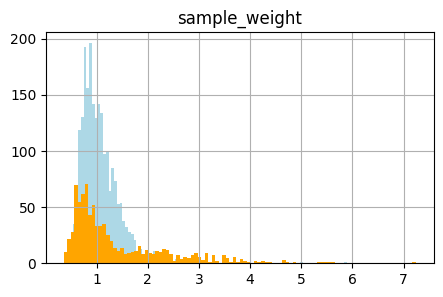

In [16]:
from shapely import distance
import numpy as np


def get_distance_matrix(
    a: gpd.GeoSeries,
    b: gpd.GeoSeries,
):
    A = a.array.to_numpy()
    B = b.array.to_numpy()

    dist_mat = distance(A[:, None], B[None, :])
    return dist_mat


dmax_by_species_m = {
    "Pipistrellus pipistrellus": 3000,  # very common, short-range forager
    "Pipistrellus pygmaeus": 3000,
    "Pipistrellus nathusii": 4000,  # more mobile pipistrelle
    "Plecotus auritus": 3000,  # typical 2–3 km range
    "Myotis daubentonii": 3000,  # riparian, but rarely >3 km from water/roost
    "Myotis nattereri": 3500,
    "Myotis mystacinus": 3000,
    "Myotis brandtii": 3000,
    "Nyctalus noctula": 6000,  # big, fast, wide-ranging
    "Nyctalus leisleri": 6000,
    "Eptesicus serotinus": 6000,  # similar movement ecology to Nyctalus
    "Vespertilio murinus": 7000,  # most mobile of the group
}

sort_density = False
limit_to_range = True
grid_size_m = 1000


d_min = 500
d_max = np.Inf  # dmax_by_species_m[latin_name]

p_dist = get_distance_matrix(
    species_presence.geometry,
    background_data.geometry,
).min(axis=0)

n_max = len(species_presence) * 10

if limit_to_range:
    # get background points within the distance range
    species_absence = background_data[(p_dist >= d_min) & (p_dist <= d_max)]
else:
    species_absence = background_data

species_absence = drop_duplicates(species_absence)


species_presence = grid_sample(
    species_presence,
    grid_size_x=grid_size_m,
    grid_size_y=grid_size_m,
)

species_absence = grid_sample(
    species_absence,
    grid_size_x=grid_size_m,
    grid_size_y=grid_size_m,
)


if sort_density:
    species_absence = species_absence.sort_values(
        by="density",
        ascending=False,
    ).head(n_max)
else:
    species_absence = species_absence.sample(
        n=min(len(species_absence), n_max), replace=False
    )


# get the sample weights
species_presence["sample_weight"] = ela.distance_weights(
    species_presence.geometry,
    n_neighbors=10,
)
species_absence["sample_weight"] = ela.distance_weights(
    species_absence.geometry,
    n_neighbors=10,
)
fig, ax = plt.subplots(figsize=(5, 3))
species_absence.hist(
    column="sample_weight",
    bins=100,
    ax=ax,
    color="lightblue",
)
species_presence.hist(
    column="sample_weight",
    bins=100,
    ax=ax,
    color="orange",
)

plt.show()


In [17]:
from leafmap.deckgl import Map as DeckMap


map_center = boundary_4326.union_all().centroid
m = DeckMap(center=(map_center.y, map_center.x), zoom=7)

m.add_gdf(
    boundary,
    zoom_to_layer=False,
    get_fill_color=[60, 60, 60, 30],
)
point_radius = 250

m.add_gdf(
    species_absence,
    zoom_to_layer=False,
    # black
    get_fill_color=[0, 0, 0, 180],
    get_radius=point_radius,
)
m.add_gdf(
    species_presence,
    zoom_to_layer=False,
    get_radius=point_radius,
    # orange
    get_fill_color=[255, 165, 0, 180],
)

print(
    f"There are {len(species_presence)} presence points and {len(species_absence)} background points for {latin_name} - {activity_type}"
)
m


There are 855 presence points and 2237 background points for Pipistrellus pipistrellus - In flight


Map(custom_attribution='', layers=(SolidPolygonLayer(get_fill_color=[60, 60, 60, 30], table=arro3.core.Table
+…

In [18]:
from typing import Any


import pandas as pd

species_data = pd.concat([species_presence, species_absence])
columns = [
    "class",
    "sample_weight",
    "geometry",
] + list(evs_to_model.data_vars.keys())
species_data = species_data[columns]
species_data.head()

class  sample_weight               geometry  \
_x_bin _y_bin                                                    
377    468    99       1       4.649885  POINT (377050 468950)   
378    466    104      1       4.317764  POINT (378150 466850)   
       480    166      1       5.415983  POINT (378850 480950)   
380    456    284      1       4.247420  POINT (380350 456750)   
382    463    33       1       3.664906  POINT (382050 463050)   

                   climate_stats_temp_ann_var  climate_bioclim_bio_4  \
_x_bin _y_bin                                                          
377    468    99                     4.252184             444.382751   
378    466    104                    4.246568             442.884338   
       480    166                    4.215598             440.655609   
380    456    284                    4.207425             439.341553   
382    463    33                     4.250282             444.986694   

                   climate_bioclim_bio_7  climate_bioclim_bio_2  \
_x_bin _y_bin                                                     
377    468    99               18.706505               6.779284   
378    466    104              18.586853               6.719837   
       480    166              18.525530               6.597031   
380    456    284              18.219826               6.615084   
382    463    33               18.555031               6.708291   

                   climate_stats_prec_ann_var  terrain_dtm  \
_x_bin _y_bin                                                
377    468    99                    24.666103   167.721405   
378    466    104                   25.187490   176.477234   
       480    166                   29.676380   329.468384   
380    456    284                   24.215467   162.795700   
382    463    33                    23.872782   149.934845   

                   climate_bioclim_bio_19  ...  \
_x_bin _y_bin                              ...   
377    468    99               358.955841  ...   
378    466    104              363.021637  ...   
       480    166              440.919922  ...   
380    456    284              354.961090  ...   
382    463    33               350.173065  ...   

                   vom_vegetation_height_max_1500m  \
_x_bin _y_bin                                        
377    468    99                          5.848682   
378    466    104                         6.323403   
       480    166                         0.494667   
380    456    284                         5.003090   
382    463    33                          8.561032   

                   vom_vegetation_height_std_1500m  \
_x_bin _y_bin                                        
377    468    99                          1.122331   
378    466    104                         1.281459   
       480    166                         0.082112   
380    456    284                         1.045102   
382    463    33                          1.907410   

                   ceh_landcover_broadleaved_woodland_1500m  \
_x_bin _y_bin                                                 
377    468    99                                 266.666656   
378    466    104                                673.888916   
       480    166                                  2.111111   
380    456    284                                328.777771   
382    463    33                                 444.777771   

                   vom_vegetation_height_mean_1500m  \
_x_bin _y_bin                                         
377    468    99                           0.478793   
378    466    104                          0.721489   
       480    166                          0.022975   
380    456    284                          0.612325   
382    463    33                           1.011868   

                   ceh_landcover_suburban_1500m  os_cover_buildings_1500m  \
_x_bin _y_bin                                                               
377    468    99                     199.777771        

# Modelling

In [19]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
%autoreload 2
from sdm.models.maxent.maxent_model import (
    create_maxent_pipeline,
    get_feature_config,
    ActivityType,
    DefaultMaxentConfig,
)

model_config = DefaultMaxentConfig(
    feature_types=["linear", "hinge"],
    beta_multiplier=4.0,
    beta_lqp=1.0,
    beta_hinge=1.0,
    beta_threshold=1.0,
    clamp=False,
    class_weights="balanced",
    n_hinge_features=10,
    n_threshold_features=10,
)
import yaml

model_id = f"{latin_name}_{activity_type}"
feature_config_path = (
    f"data/sdm_tuning/{model_id.replace(' ', '_')}/variables_config.yml"
)
model_config_path = f"data/sdm_tuning/{model_id.replace(' ', '_')}/model_config.yml"


with open(feature_config_path, "r") as f:
    feature_config = yaml.safe_load(f)

with open(model_config_path, "r") as f:
    model_config = yaml.safe_load(f)


feature_config = feature_config["variables"]


model_config = model_config["model"]["maxent"]
model_config["clamp"] = True


model_config = DefaultMaxentConfig(**model_config)

maxent_model = create_maxent_pipeline(
    feature_names=feature_config,
    maxent_n_jobs=-1,
    model_config=model_config,
)

maxent_model


Pipeline(steps=[('feature_selection',
                 FeatureSubsetter(feature_names=['terrain_dtm',
                                                 'climate_stats_temp_ann_avg',
                                                 'os_distance_distance_to_buildings',
                                                 'terrain_stats_aspect_eastness_slope',
                                                 'ceh_landcover_wetland',
                                                 'vom_vegetation_height_max_500m',
                                                 'os_cover_water_500m',
                                                 'ceh_landcover_urban_500m',
                                                 'ceh_landcover_improved_grassland_500m',
                                                 'vom_vegetation_he...
                                     subsample=20000)),
                ('standard_scaling', StandardScaler()),
                ('maxent',
                 MaxentModel(beta_categorical=3.735997391894775,
                             beta_hinge=0.7435778936664555,
                             beta_lqp=1.4629767229345276,
                             beta_multiplier=0.9431335698355248,
                             beta_threshold=1.4629767229345276,
                             class_weights='balanced',
                             feature_types=['linear', 'hinge', 'quadratic'],
                             n_cpus=-1, n_hinge_features=2,
                             n_threshold_features=0))])

In [21]:
print(latin_name)
print(activity_type)

Pipistrellus pipistrellus
In flight


In [22]:
import mlflow


def to_percent(x):
    return (x * 100).round(1)


# Configure MLflow from project config so we use the same tracking store/experiment
tracking_uri = config["mlflow"]["tracking_uri"]
experiment_name = config["mlflow"]["experiment_name"]
mlflow.set_tracking_uri(tracking_uri)
mlflow.set_experiment(experiment_name)


# with mlflow.start_run():
final_model, cv_models, cv_scores = evaluate_and_train_maxent_model(
    model=maxent_model,
    occurrence_gdf=species_data,
    metric_fn=roc_auc_score,
    n_cv_folds=3,
)


print(f"Mean AUC: {to_percent(cv_scores.mean())}%")
print(f"Variation: +/- {to_percent(cv_scores.std())}%")

2025/12/06 21:03:28 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2025/12/06 21:03:28 INFO mlflow.store.db.utils: Updating database tables
2025-12-06 21:03:28 INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
2025-12-06 21:03:28 INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
2025-12-06 21:03:28 INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
2025-12-06 21:03:28 INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


Mean AUC: 81.2%
Variation: +/- 7.3%


In [23]:
model_id = f"{latin_name}-{activity_type}"

In [24]:
from sdm.models.maxent.maxent_model import apply_models_to_raster

prediction_paths = []
# Define the arguments for each task

path_predict = Path(f"data/temp/prediction-{latin_name}-{activity_type}.tif")
path_predict.parent.mkdir(parents=True, exist_ok=True)

apply_models_to_raster(
    models={
        model_id: final_model,
    },
    raster_path=ev_path,
    output_path=str(path_predict),
    windowed=True,
    window_size=512,
)


Processing windows:   0%|                              | 0/16 [00:00<?, ?it/s]

In [25]:
from rasterio.mask import mask
import numpy as np
import rasterio as rio
import rioxarray as rxr

# mask the prediction raster with the boundary
predictions_masked = Path(
    f"data/temp/prediction-{latin_name}-{activity_type}-masked.tif"
)

predictions = rxr.open_rasterio(path_predict)
predictions = predictions.rio.clip(boundary.geometry)
predictions = predictions.rio.reproject(4326)
predictions.rio.to_raster(predictions_masked)

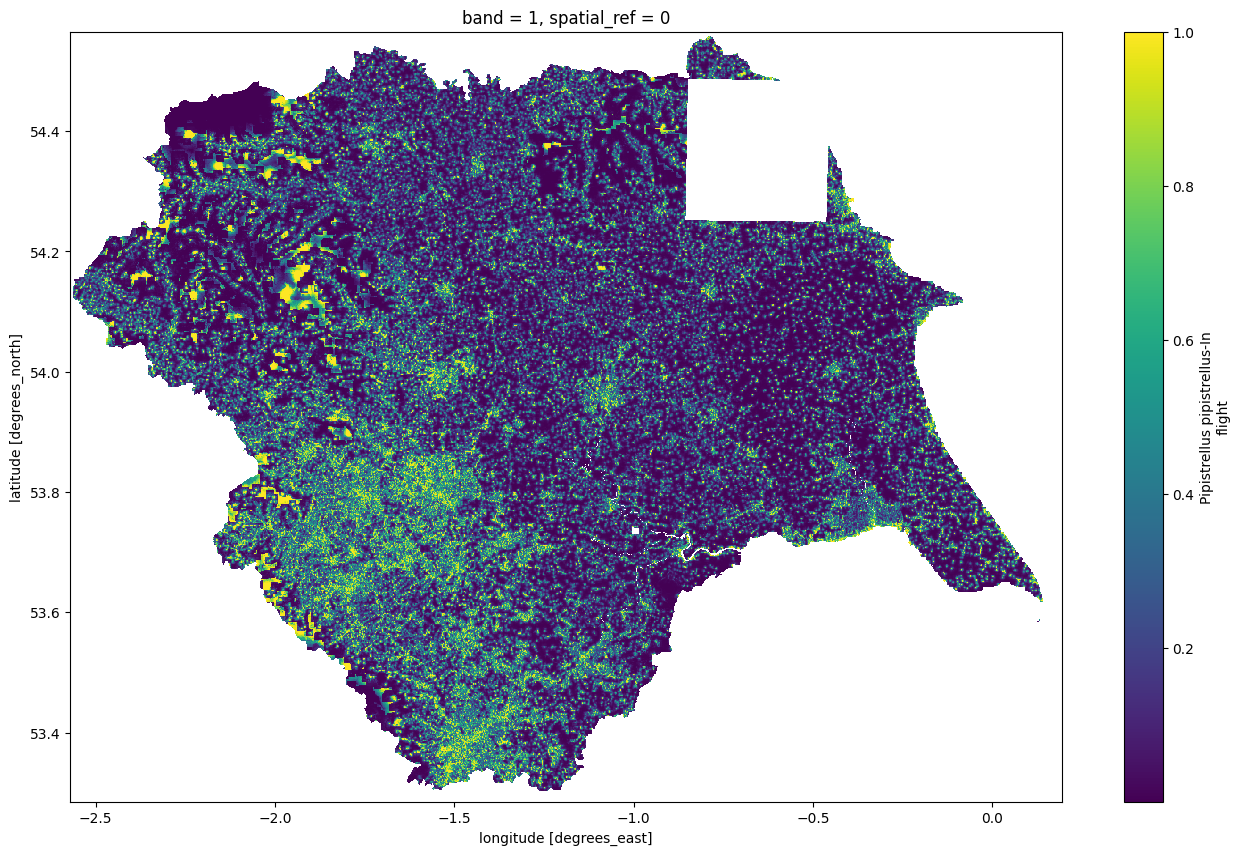

In [26]:
predictions.where(predictions > 0.0).plot(figsize=(16, 10))

In [27]:
import leafmap

m = leafmap.Map()
m.zoom_to_gdf(boundary_4326)
m.add_basemap("HYBRID")
m.add_raster(
    str(predictions_masked),
    layer_name="Predictions",
    cmap="viridis",
    nodata=np.nan,
    opacity=0.5,
)
m.add_gdf(
    species_presence,
    layer_name="Presence",
    point_style={"color": "orange", "weight": 1, "opacity": 0.7, "radius": 3},
)
m

Map(center=[53.925256000000005, -1.1879715000000002], controls=(ZoomControl(options=['position', 'zoom_in_text…

In [28]:
import numpy as np
import shap
import pandas as pd
from typing import Tuple, Optional


def compute_shap_for_pipeline(
    model,
    X: pd.DataFrame,
    feature_names,
    positive_class: int = 1,
    sample_size: int = 200,
    n_explain: Optional[int] = 200,
    random_state: int = 42,
) -> Tuple[shap.Explainer, shap._explanation.Explanation, pd.DataFrame]:
    """
    Compute SHAP values for a scikit-learn pipeline that supports predict_proba.

    Parameters
    ----------
    model
        Fitted sklearn Pipeline (or any estimator) with predict_proba.
    X
        DataFrame of input features (same structure as used for training).
    feature_names
        Sequence of feature names (columns of X, or subset/order used for model).
    positive_class
        Index of the positive class in predict_proba output.
    sample_size
        Number of background samples for the explainer.
    n_explain
        Number of rows to explain. If None, use all rows of X.
    random_state
        Seed for sampling.

    Returns
    -------
    explainer
        SHAP explainer object (can be reused).
    shap_values
        SHAP Explanation object for X_explain.
    X_explain
        DataFrame of rows that shap_values correspond to.
    """

    # Ensure we only use the requested features, in a consistent order
    X = X[list(feature_names)]

    # Background sample
    sample_size = min(sample_size, len(X))
    background = X.sample(n=sample_size, random_state=random_state)

    # Prediction function returning probability for positive class
    def predict_fn(data):
        proba = model.predict_proba(data)
        return proba[:, positive_class]

    explainer = shap.Explainer(
        predict_fn,
        background,
        algorithm="permutation",
        model_output="probability",
    )

    # Data to explain
    if n_explain is None:
        X_explain = X
    else:
        n_explain = min(n_explain, len(X))
        X_explain = X.sample(n=n_explain, random_state=random_state + 1)

    shap_values = explainer(X_explain)

    return explainer, shap_values, X_explain


explainer, shap_values, X_explain = compute_shap_for_pipeline(
    final_model,
    ev_gdf[feature_config],
    feature_names=feature_config,
    sample_size=100,
)


PermutationExplainer explainer: 201it [00:33,  4.48it/s]                         


In [29]:
print(latin_name)
print(activity_type)

Pipistrellus pipistrellus
In flight


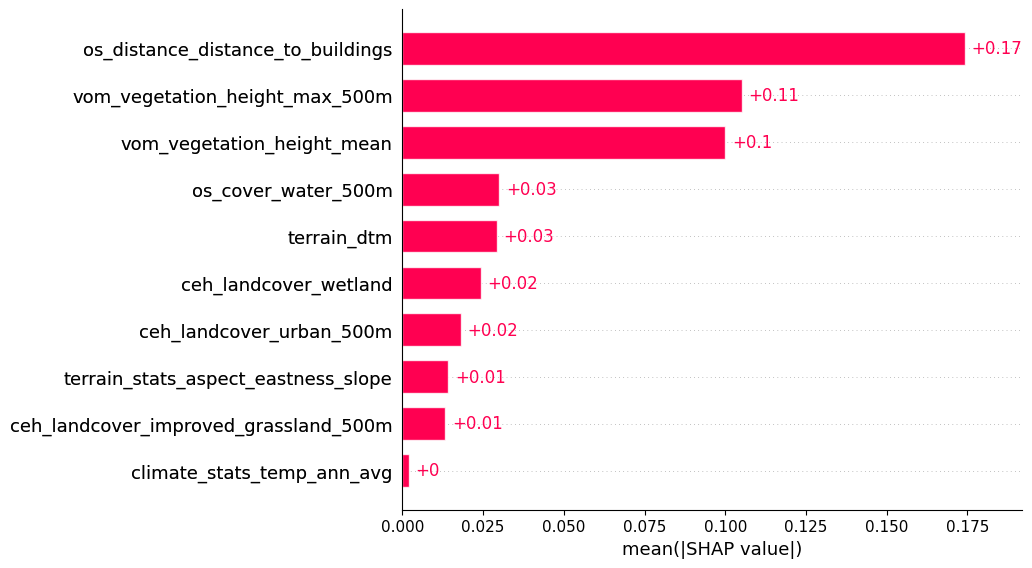

In [30]:
import numpy as np
import shap

# shap_values from your explainer call (for the positive class)
values = shap_values.values  # (n_samples, n_features)

# Global importance
shap.plots.bar(shap_values, max_display=25)  # new API


In [31]:
# order feature names by descending shap values
variable_contributions = pd.DataFrame(
    abs(shap_values.values.mean(axis=0)), index=feature_config, columns=["shap_mean"]
).sort_values(by="shap_mean", ascending=False)

variable_contributions

,shap_mean
vom_vegetation_height_mean,0.028592
vom_vegetation_height_max_500m,0.024181
os_distance_distance_to_buildings,0.009378
terrain_stats_aspect_eastness_slope,0.002276
ceh_landcover_urban_500m,0.002228
os_cover_water_500m,0.001719
ceh_landcover_improved_grassland_500m,0.001097
ceh_landcover_wetland,0.000866
climate_stats_temp_ann_avg,0.000288
terrain_dtm,0.000101


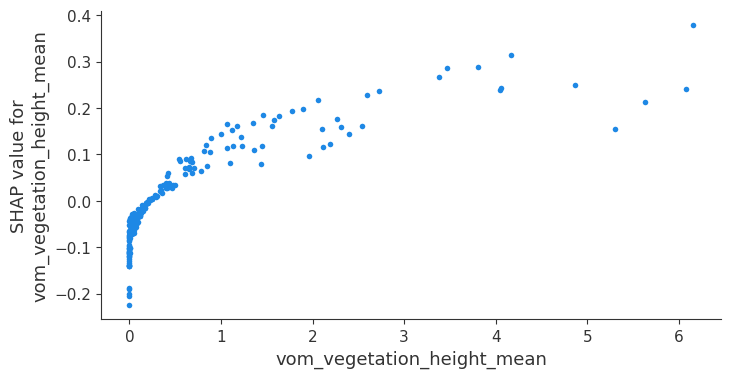

In [32]:
import numpy as np
import shap
import matplotlib.pyplot as plt


def plot_filtered_shap_dependence(
    feature_name,
    X_df,
    shap_values,
    p_low=1,
    p_high=99,
    interaction_index=None,
    fig=None,
    ax=None,
    figsize=(6, 4),
):
    """
    SHAP dependence plot filtered to percentile range, with support for
    passing in existing fig/ax so multiple plots can be placed in a panel.

    Parameters
    ----------
    feature_name : str
        Feature to plot.
    X_df : pandas.DataFrame
        Input features for the SHAP values.
    shap_values : shap.Explanation
        SHAP values aligned with X_df.
    p_low, p_high : int|float
        Percentile bounds for trimming the feature range.
    interaction_index : str|int|None
        Feature used for colour (None = same feature).
    fig, ax : matplotlib Figure/Axes or None
        If provided, SHAP will draw into this axis.
    figsize : tuple
        Only used if fig/ax are not provided.

    Returns
    -------
    fig, ax : Figure and Axes
    """

    # Compute percentile bounds
    low, high = np.percentile(X_df[feature_name], [p_low, p_high])

    # Filter rows to percentile limits
    mask = (X_df[feature_name] >= low) & (X_df[feature_name] <= high)
    X_filtered = X_df.loc[mask]
    shap_filtered = shap_values.values[mask, :]

    # Create fig/ax only if not provided
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        # If ax provided but fig not, use ax.figure
        if fig is None:
            fig = ax.figure

    # Draw SHAP plot on this axis
    shap.dependence_plot(
        feature_name,
        shap_filtered,
        X_filtered,
        interaction_index=interaction_index,
        ax=ax,
        show=False,
    )

    return fig, ax


fig, ax = plt.subplots(figsize=(8, 4))

fig, ax = plot_filtered_shap_dependence(
    variable_contributions.index[0],
    X_explain,
    shap_values,
    p_low=5,
    p_high=95,
    fig=fig,
    ax=ax,
)

fig.show()


In [ ]:
# explain a single point

x, y = 401195, 475151

point_evs = evs_to_model.sel(x=[x], y=[y], method="nearest").to_dataframe()

point_features = point_evs[feature_config]

point_shap_values = explainer.shap_values(point_features)
point_shap_df = pd.DataFrame(
    data={
        "variable": feature_config,
        "input_value": point_features.values[0],
        "shap_score": point_shap_values[0],
    }
).sort_values(by="shap_score", ascending=False)


point_shap_df


,variable,input_value,shap_score
5,vom_vegetation_height_max_500m,0.000000,0.264592
4,ceh_landcover_wetland,10000.000000,0.182921
8,ceh_landcover_improved_grassland_500m,0.000000,0.112204
7,ceh_landcover_urban_500m,0.000000,0.060493
6,os_cover_water_500m,3.880000,0.024463
1,climate_stats_temp_ann_avg,6.674460,0.007628
3,terrain_stats_aspect_eastness_slope,-1.304275,-0.024802
0,terrain_dtm,505.142395,-0.032958
9,vom_vegetation_height_mean,0.000000,-0.180182
2,os_distance_distance_to_buildings,2650.039795,-0.557091
